<a href="https://colab.research.google.com/github/GuilhermeMBertolo/CIC_IDS2017/blob/main/CIC_IDS_2017_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIC-IDS-2017 | KNN


In [ ]:
# =====================================================
# 1. Ambiente e configuracao experimental
# =====================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SEED = 314159
np.random.seed(SEED)

PASTA = '/content/drive/MyDrive/CIC-IDS-2017/'
ARQUIVOS = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

NOMES_CLASSES = [
    'BENIGN', 'DoS', 'DDoS', 'Brute Force',
    'Web Attack', 'Reconnaissance', 'Bot', 'Raros',
]

# None preserva o protocolo completo. Use um limite somente se todos os
# algoritmos forem reexecutados com a mesma amostra estratificada.
MAX_LINHAS_TREINO = None
MAX_LINHAS_VALIDACAO = None
MAX_LINHAS_TESTE = None


In [ ]:
# =====================================================
# 2. Carga, limpeza e agrupamento das classes
# =====================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ambiente local detectado. Ajuste PASTA para a pasta dos CSVs.')


def carregar_e_preparar(pasta, arquivos):
    tabelas = []
    for arquivo in arquivos:
        dados = pd.read_csv(os.path.join(pasta, arquivo), low_memory=False)
        dados.columns = dados.columns.str.strip()
        tabelas.append(dados)

    df = pd.concat(tabelas, ignore_index=True)
    df['Label'] = df['Label'].replace({
        'Web Attack Ã¯Â¿Â½ Brute Force': 'Web Attack - Brute Force',
        'Web Attack Ã¯Â¿Â½ Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack Ã¯Â¿Â½ XSS': 'Web Attack - XSS',
        'Web Attack � Brute Force': 'Web Attack - Brute Force',
        'Web Attack � Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack � XSS': 'Web Attack - XSS',
    })

    antes = len(df)
    df = df.dropna()
    colunas_numericas = df.select_dtypes(include=np.number).columns
    df = df.loc[np.isfinite(df[colunas_numericas]).all(axis=1)]
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Linhas removidas na limpeza: {antes - len(df):,}')

    grupos = {
        'BENIGN': 'BENIGN',
        'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
        'DoS Slowhttptest': 'DoS', 'DoS slowloris': 'DoS',
        'DDoS': 'DDoS',
        'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Web Attack - Brute Force': 'Web Attack',
        'Web Attack - Sql Injection': 'Web Attack',
        'Web Attack - XSS': 'Web Attack',
        'PortScan': 'Reconnaissance', 'Bot': 'Bot',
        'Infiltration': 'Raros', 'Heartbleed': 'Raros',
    }
    codigos = {nome: indice for indice, nome in enumerate(NOMES_CLASSES)}

    df['Label_grupo'] = df['Label'].map(grupos)
    df = df.dropna(subset=['Label_grupo']).copy()
    df['Label_final'] = df['Label_grupo'].map(codigos).astype(int)

    X = df.drop(columns=['Label', 'Label_grupo', 'Label_final'])
    y = df['Label_final']
    print(f'Dataset final: {X.shape[0]:,} linhas e {X.shape[1]} atributos')
    display(df['Label_grupo'].value_counts().reindex(NOMES_CLASSES).to_frame('quantidade'))
    return X, y


def amostra_estratificada(X, y, limite):
    if limite is None or len(X) <= limite:
        return X, y

    contagens = y.value_counts()
    classes_raras = contagens[contagens < 2].index
    mascara_raras = y.isin(classes_raras)
    X_raras, y_raras = X.loc[mascara_raras], y.loc[mascara_raras]
    X_comuns, y_comuns = X.loc[~mascara_raras], y.loc[~mascara_raras]
    tamanho_comum = limite - len(X_raras)

    X_amostra, _, y_amostra, _ = train_test_split(
        X_comuns, y_comuns, train_size=tamanho_comum,
        stratify=y_comuns, random_state=SEED,
    )
    X_amostra = pd.concat([X_amostra, X_raras]).sample(frac=1, random_state=SEED)
    return X_amostra, y.loc[X_amostra.index]


Mounted at /content/drive


In [ ]:
# =====================================================
# 3. Divisao estratificada: 80% treino, 10% validacao, 10% teste
# =====================================================

X, y = carregar_e_preparar(PASTA, ARQUIVOS)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED, shuffle=True,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED, shuffle=True,
)

X_train, y_train = amostra_estratificada(X_train, y_train, MAX_LINHAS_TREINO)
X_val, y_val = amostra_estratificada(X_val, y_val, MAX_LINHAS_VALIDACAO)
X_test, y_test = amostra_estratificada(X_test, y_test, MAX_LINHAS_TESTE)

resumo_divisao = pd.DataFrame({
    'Conjunto': ['Treino', 'Validacao', 'Teste'],
    'Linhas': [len(X_train), len(X_val), len(X_test)],
})
display(resumo_divisao)


Linhas removidas na limpeza: 309,945
Dataset final: 2,520,798 linhas e 78 atributos


,quantidade
Label_grupo,
BENIGN,2095057
DoS,193745
DDoS,128014
Brute Force,9150
Web Attack,2143
Reconnaissance,90694
Bot,1948
Raros,47


,Conjunto,Linhas
0,Treino,2016638
1,Validacao,252080
2,Teste,252080


In [ ]:
# =====================================================
# 4. Selecao de atributos por importancia do XGBoost
# =====================================================

# Mesmo criterio de selecao usado no MLP de referencia: 95% da importancia acumulada.
seletor_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(NOMES_CLASSES),
    eval_metric='mlogloss',
    random_state=SEED,
    tree_method='hist',
    n_estimators=200,
    learning_rate=0.10,
    max_depth=6,
    n_jobs=-1,
)
seletor_xgb.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': seletor_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)
importancias['Importancia_acumulada'] = importancias['Importance'].cumsum() / importancias['Importance'].sum()

features_selecionadas = importancias.loc[
    importancias['Importancia_acumulada'] <= 0.95,
    'Feature',
].tolist()

if not features_selecionadas:
    features_selecionadas = [importancias.iloc[0]['Feature']]

print(f'Features selecionadas: {len(features_selecionadas)}')
display(importancias.head(20))


Features selecionadas: 21


,Feature,Importance,Importancia_acumulada
13,Bwd Packet Length Std,0.213418,0.213418
74,Idle Mean,0.134505,0.347923
76,Idle Max,0.116660,0.464584
12,Bwd Packet Length Mean,0.061026,0.525610
30,Fwd PSH Flags,0.054695,0.580304
68,act_data_pkt_fwd,0.053228,0.633532
52,Average Packet Size,0.050233,0.683766
4,Total Length of Fwd Packets,0.044570,0.728336
14,Flow Bytes/s,0.031720,0.760056
35,Bwd Header Length,0.031349,0.791405


In [ ]:
# =====================================================
# 5. Normalizacao ajustada somente no treino
# =====================================================

scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train[features_selecionadas])
X_val_z = scaler.transform(X_val[features_selecionadas])
X_test_z = scaler.transform(X_test[features_selecionadas])


In [ ]:
# =====================================================
# 6. Escolha rapida de k no conjunto de validacao
# =====================================================

# No KNN, a predicao e a parte mais cara: cada exemplo precisa ser comparado
# com muitos exemplos de treino. A escolha de k usa amostras estratificadas
# para reduzir o custo sem perder a validacao separada.
MAX_TREINO_BUSCA_K = 60_000
MAX_VALIDACAO_BUSCA_K = 20_000


def amostra_estratificada_array(X_array, y_array, max_linhas, seed):
    y_array = np.asarray(y_array)
    if max_linhas is None or len(y_array) <= max_linhas:
        return X_array, y_array

    indices = np.arange(len(y_array))
    indices_amostra, _ = train_test_split(
        indices,
        train_size=max_linhas,
        stratify=y_array,
        random_state=seed,
        shuffle=True,
    )
    return X_array[indices_amostra], y_array[indices_amostra]


X_train_k, y_train_k = amostra_estratificada_array(
    X_train_z, y_train.to_numpy(), MAX_TREINO_BUSCA_K, SEED,
)
X_val_k, y_val_k = amostra_estratificada_array(
    X_val_z, y_val.to_numpy(), MAX_VALIDACAO_BUSCA_K, SEED + 1,
)

print(f'Amostra para escolha de k: {len(X_train_k):,} treino e {len(X_val_k):,} validacao')

valores_k = [3, 5, 7, 9]
resultados_validacao = []

for k in valores_k:
    modelo = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='euclidean',
        algorithm='brute',
        n_jobs=-1,
    )
    modelo.fit(X_train_k, y_train_k)
    pred_val = modelo.predict(X_val_k)
    resultados_validacao.append({
        'k': k,
        'Accuracy': accuracy_score(y_val_k, pred_val),
        'F1_weighted': f1_score(y_val_k, pred_val, average='weighted', zero_division=0),
        'F1_macro': f1_score(y_val_k, pred_val, average='macro', zero_division=0),
    })

tabela_validacao = pd.DataFrame(resultados_validacao).sort_values('Accuracy', ascending=False)
display(tabela_validacao.style.format({'Accuracy': '{:.4f}', 'F1_weighted': '{:.4f}', 'F1_macro': '{:.4f}'}))

melhor_k = int(tabela_validacao.iloc[0]['k'])
print(f'Melhor k pela acuracia de validacao: {melhor_k}')


Amostra para escolha de k: 60,000 treino e 20,000 validacao


,k,Accuracy,F1_weighted,F1_macro
0,3,0.9949,0.9949,0.9119
1,5,0.9944,0.9944,0.8998
3,9,0.9944,0.9944,0.9049
2,7,0.9942,0.9942,0.9048


Melhor k pela acuracia de validacao: 3


In [ ]:
# =====================================================
# 7. Treino final balanceado e avaliacao no teste isolado
# =====================================================

# Meio termo entre qualidade e tempo:
# - usa treino + validacao apos escolher k;
# - limita a base de referencia do KNN, pois ela impacta diretamente cada predicao;
# - avalia em uma amostra estratificada do teste isolado para evitar execucoes de horas.
MAX_TREINO_FINAL_KNN = 100_000
MAX_TESTE_AVALIACAO_KNN = 40_000

X_modelo = np.vstack([X_train_z, X_val_z])
y_modelo = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])

X_modelo_knn, y_modelo_knn = amostra_estratificada_array(
    X_modelo,
    y_modelo,
    MAX_TREINO_FINAL_KNN,
    SEED + 2,
)
X_test_eval, y_test_eval = amostra_estratificada_array(
    X_test_z,
    y_test.to_numpy(),
    MAX_TESTE_AVALIACAO_KNN,
    SEED + 3,
)

print(f'Amostra usada no treino final do KNN: {len(X_modelo_knn):,} de {len(X_modelo):,} linhas')
print(f'Amostra usada na avaliacao do teste: {len(X_test_eval):,} de {len(X_test_z):,} linhas')

knn_final = KNeighborsClassifier(
    n_neighbors=melhor_k,
    weights='distance',
    metric='euclidean',
    algorithm='brute',
    n_jobs=-1,
)
knn_final.fit(X_modelo_knn, y_modelo_knn)
y_pred = knn_final.predict(X_test_eval)

metricas = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted', 'F1 macro', 'Balanced accuracy'],
    'Valor': [
        accuracy_score(y_test_eval, y_pred),
        precision_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        recall_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        f1_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        f1_score(y_test_eval, y_pred, average='macro', zero_division=0),
        balanced_accuracy_score(y_test_eval, y_pred),
    ],
})
metricas['Valor (%)'] = (metricas['Valor'] * 100).round(2)
display(metricas[['Metrica', 'Valor (%)']])

print(classification_report(
    y_test_eval, y_pred, labels=range(len(NOMES_CLASSES)),
    target_names=NOMES_CLASSES, digits=4, zero_division=0,
))


Amostra usada no treino final do KNN: 100,000 de 2,268,718 linhas
Amostra usada na avaliacao do teste: 40,000 de 252,080 linhas


,Metrica,Valor (%)
0,Accuracy,99.56
1,Precision weighted,99.55
2,Recall weighted,99.56
3,F1 weighted,99.55
4,F1 macro,77.44
5,Balanced accuracy,75.80


                precision    recall  f1-score   support

        BENIGN     0.9976    0.9973    0.9975     33244
           DoS     0.9879    0.9841    0.9860      3074
          DDoS     0.9961    0.9975    0.9968      2032
   Brute Force     0.9931    0.9931    0.9931       145
    Web Attack     1.0000    0.7059    0.8276        34
Reconnaissance     0.9762    0.9986    0.9873      1439
           Bot     0.4286    0.3871    0.4068        31
         Raros     0.0000    0.0000    0.0000         1

      accuracy                         0.9956     40000
     macro avg     0.7974    0.7580    0.7744     40000
  weighted avg     0.9955    0.9956    0.9955     40000



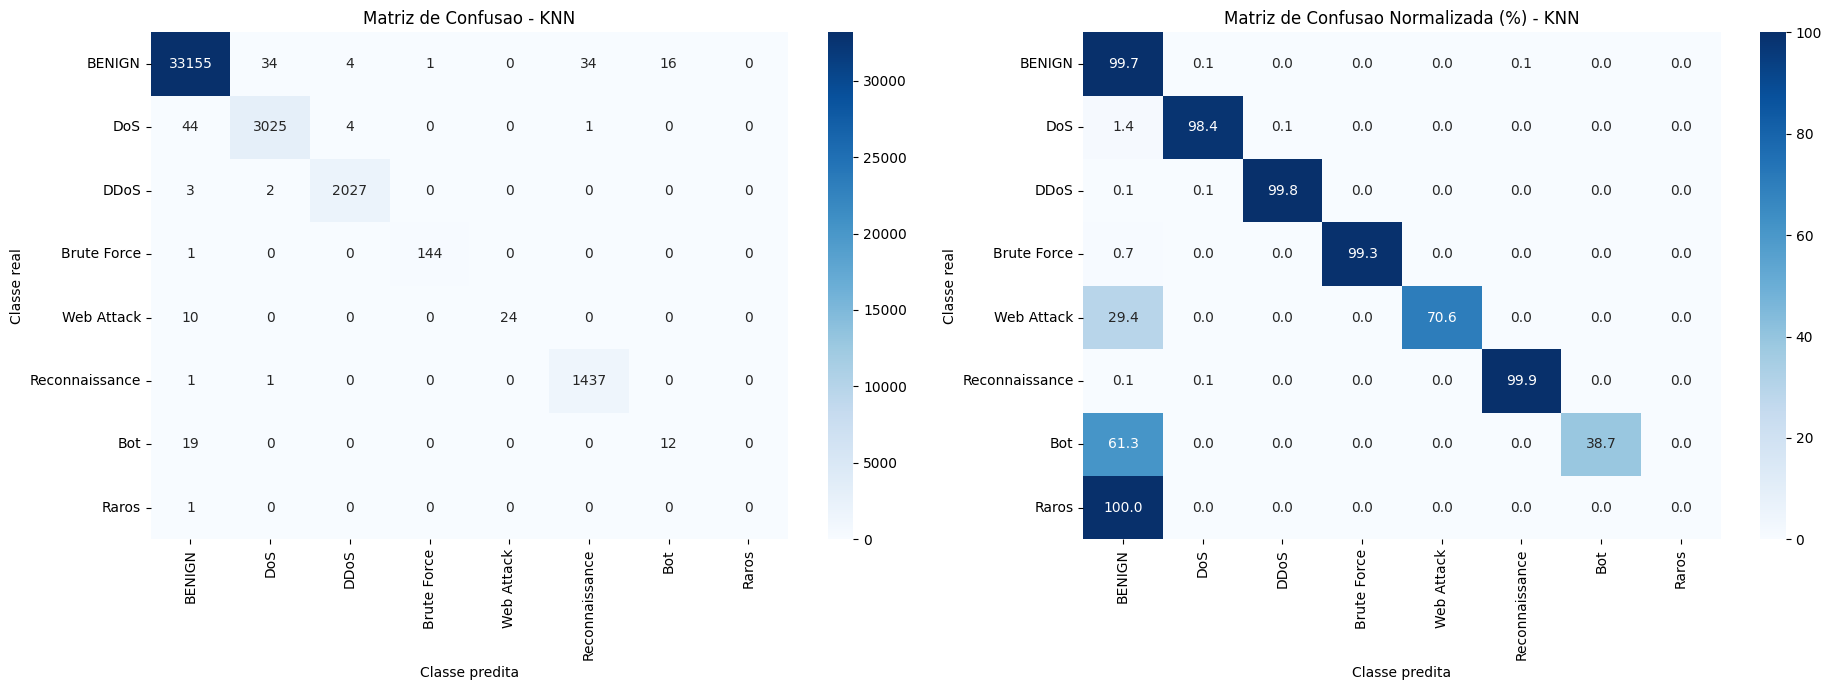

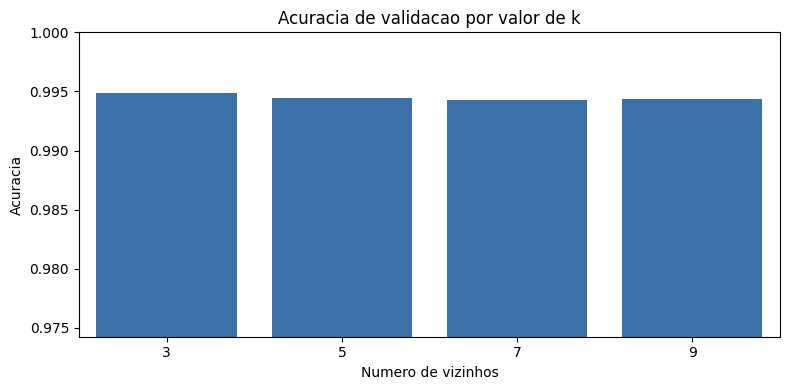

In [ ]:
# =====================================================
# 8. Analise visual dos resultados
# =====================================================

cm = confusion_matrix(y_test_eval, y_pred, labels=range(len(NOMES_CLASSES)))
cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(pd.DataFrame(cm, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set(title='Matriz de Confusao - KNN', xlabel='Classe predita', ylabel='Classe real')

sns.heatmap(pd.DataFrame(cm_percent, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set(title='Matriz de Confusao Normalizada (%) - KNN', xlabel='Classe predita', ylabel='Classe real')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=tabela_validacao, x='k', y='Accuracy', color='#2a6fbb')
plt.ylim(max(0, tabela_validacao['Accuracy'].min() - 0.02), 1.0)
plt.title('Acuracia de validacao por valor de k')
plt.xlabel('Numero de vizinhos')
plt.ylabel('Acuracia')
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================
# 9. Quantidade de acertos e desvio padrao
# =====================================================

# Quantidade absoluta de acertos/erros na avaliacao principal da etapa 7.
quantidade_acertos = int((y_test_eval == y_pred).sum())
quantidade_erros = int((y_test_eval != y_pred).sum())
total_avaliado = len(y_test_eval)

resumo_acertos = pd.DataFrame({
    'Indicador': ['Acertos', 'Erros', 'Total avaliado', 'Taxa de acerto (%)'],
    'Valor': [
        quantidade_acertos,
        quantidade_erros,
        total_avaliado,
        round(quantidade_acertos / total_avaliado * 100, 2),
    ],
})
display(resumo_acertos)

# Estimativa de media e desvio padrao por repeticoes no teste isolado.
# O modelo nao e retreinado; apenas avaliamos amostras estratificadas diferentes
# do teste para controlar o tempo de execucao.
N_REPETICOES_DESVIO = 5
MAX_TESTE_DESVIO_KNN = 10_000

resultados_repetidos = []

for repeticao in range(N_REPETICOES_DESVIO):
    X_rep, y_rep = amostra_estratificada_array(
        X_test_z,
        y_test.to_numpy(),
        MAX_TESTE_DESVIO_KNN,
        SEED + 100 + repeticao,
    )
    pred_rep = knn_final.predict(X_rep)
    resultados_repetidos.append({
        'Repeticao': repeticao + 1,
        'Total avaliado': len(y_rep),
        'Acertos': int((y_rep == pred_rep).sum()),
        'Erros': int((y_rep != pred_rep).sum()),
        'Accuracy': accuracy_score(y_rep, pred_rep),
        'Precision weighted': precision_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'Recall weighted': recall_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 weighted': f1_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 macro': f1_score(y_rep, pred_rep, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_rep, pred_rep),
    })

resultados_repetidos = pd.DataFrame(resultados_repetidos)
display(resultados_repetidos)

resumo_desvio = resultados_repetidos.drop(columns=['Repeticao']).agg(['mean', 'std']).T
resumo_desvio.columns = ['Media', 'Desvio padrao']

for coluna in ['Media', 'Desvio padrao']:
    resumo_desvio[coluna] = resumo_desvio[coluna].round(4)

display(resumo_desvio)


,Indicador,Valor
0,Acertos,39824.00
1,Erros,176.00
2,Total avaliado,40000.00
3,Taxa de acerto (%),99.56


,Repeticao,Total avaliado,Acertos,Erros,Accuracy,Precision weighted,Recall weighted,F1 weighted,F1 macro,Balanced accuracy
0,1,10000,9947,53,0.9947,0.994536,0.9947,0.994531,0.845910,0.816556
1,2,10000,9949,51,0.9949,0.994781,0.9949,0.994781,0.884554,0.851881
2,3,10000,9961,39,0.9961,0.995907,0.9961,0.995973,0.852698,0.833448
3,4,10000,9964,36,0.9964,0.996437,0.9964,0.996380,0.921234,0.907726
4,5,10000,9965,35,0.9965,0.996481,0.9965,0.996483,0.946417,0.939640


,Media,Desvio padrao
Total avaliado,10000.0000,0.0000
Acertos,9957.2000,8.5557
Erros,42.8000,8.5557
Accuracy,0.9957,0.0009
Precision weighted,0.9956,0.0009
Recall weighted,0.9957,0.0009
F1 weighted,0.9956,0.0009
F1 macro,0.8902,0.0434
Balanced accuracy,0.8699,0.0519
